# (2) Exploratory Data Analysis

Previously, we downloaded audio samples and prepared the meatadata from two datasets (Speech Accent Archive and Common Voice). Now let's explore the metadata and the audio samples.

## The Speech Accent Archive

### Metadata

In [1]:
import pandas as pd

speech_accent_df = pd.read_csv("./datasets/speech_accent_archive/metadata.csv")
speech_accent_df

,filename,gender,birthplace,country,age_english_onset,accent,age
0,arabic10.mp3,male,"cairo, egypt",egypt,5.0,arabic,26.0
1,arabic12.mp3,male,"baghdad, iraq",iraq,11.0,arabic,32.0
2,arabic13.mp3,male,"zabbougha, lebanon",lebanon,15.0,arabic,25.0
3,arabic2.mp3,male,"damascus, syria",syria,2.5,arabic,18.0
4,arabic3.mp3,male,"doha, qatar",qatar,9.0,arabic,24.0
...,...,...,...,...,...,...,...
1079,english601.mp3,male,"fairfax, virginia, usa",usa,0.0,english,49.0
1080,english609.mp3,female,"narrandera, new south wales, australia",australia,0.0,english,20.0
1081,spanish234.mp3,male,"maracaibo, venezuela",venezuela,13.0,spanish,51.0
1082,arabic165.mp3,female,"beirut, lebanon",lebanon,12.0,arabic,62.0


It seems that the above dataframe has no missing values. Let's double check to see if that is the case, i.e check if the code cell below returns no rows with missing data.

In [2]:
len(speech_accent_df[speech_accent_df.isnull().any(axis=1)])

0

Since the age column stores numerical, we can extract a statistical summary on the column.

In [3]:
speech_accent_df.age.describe()

count    1084.000000
mean       33.511531
std        15.484440
min         6.000000
25%        21.000000
50%        28.000000
75%        42.000000
max        93.000000
Name: age, dtype: float64

From here, we can bin the numerical ages into the following 6 categories.

In [4]:
def get_age_category(age):
    if age < 20: return 'under-20'
    elif 20 <= age <= 29: return '20-29'
    elif 30 <= age <= 39: return '30-39'
    elif 40 <= age <= 49: return '40-49'
    elif 50 <= age <= 59: return '50-59'
    else: return '60+'

speech_accent_df.age = speech_accent_df.age.apply(lambda age: get_age_category(age))
speech_accent_df.to_csv("./datasets/speech_accent_archive/metadata(1).csv", index=False)
speech_accent_df

,filename,gender,birthplace,country,age_english_onset,accent,age
0,arabic10.mp3,male,"cairo, egypt",egypt,5.0,arabic,20-29
1,arabic12.mp3,male,"baghdad, iraq",iraq,11.0,arabic,30-39
2,arabic13.mp3,male,"zabbougha, lebanon",lebanon,15.0,arabic,20-29
3,arabic2.mp3,male,"damascus, syria",syria,2.5,arabic,under-20
4,arabic3.mp3,male,"doha, qatar",qatar,9.0,arabic,20-29
...,...,...,...,...,...,...,...
1079,english601.mp3,male,"fairfax, virginia, usa",usa,0.0,english,40-49
1080,english609.mp3,female,"narrandera, new south wales, australia",australia,0.0,english,20-29
1081,spanish234.mp3,male,"maracaibo, venezuela",venezuela,13.0,spanish,50-59
1082,arabic165.mp3,female,"beirut, lebanon",lebanon,12.0,arabic,60+


Now that we assigned ages into age categories, we will create a bar chart that describes the age catgeory distribution.

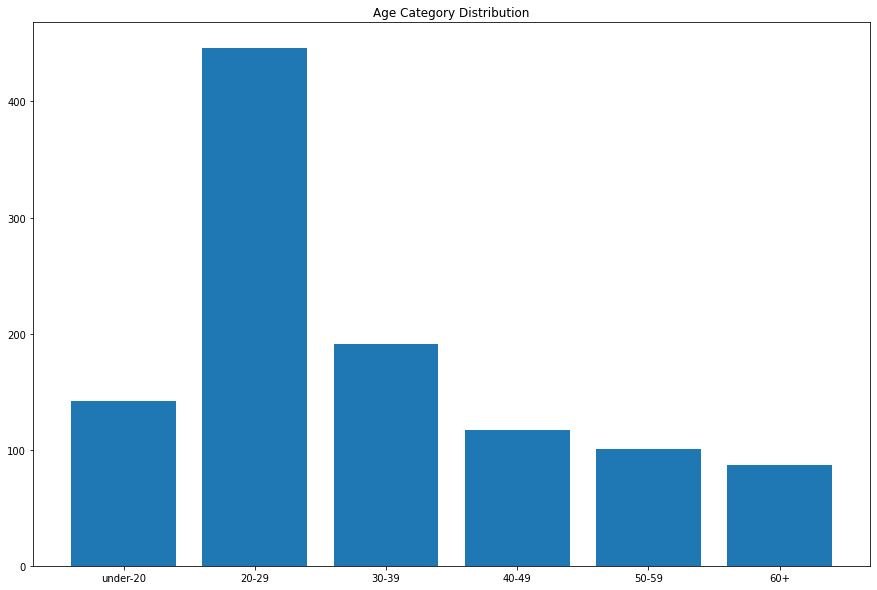

In [5]:
from helpers import *

age_distribution(speech_accent_df)

A majority of speakers from the Speech Accent Archive are in their 20s. The age group with the fewest speakers are the ones who are in their 60s or above.

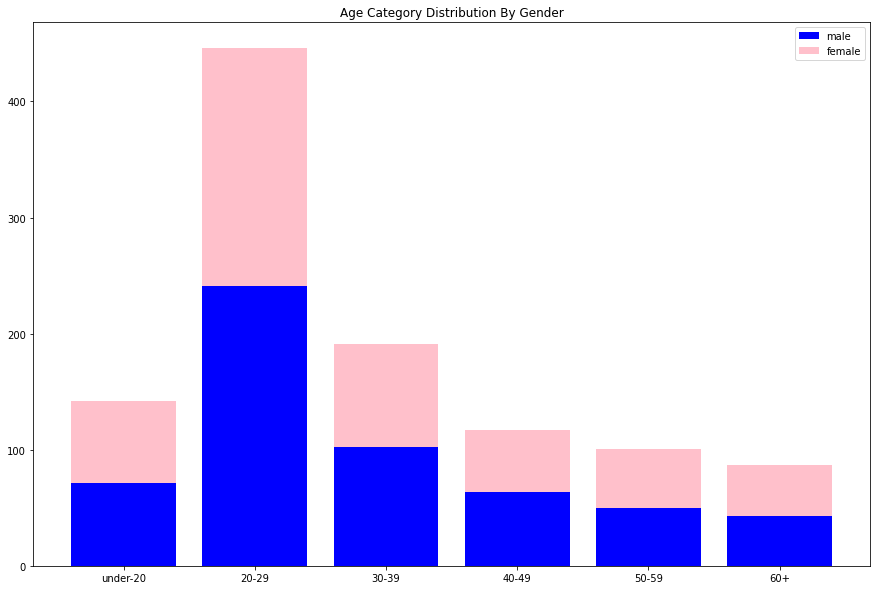

In [6]:
from helpers import *

speech_accent_age_distribution_by_gender(speech_accent_df)

By breaking down the same barchart by gender, it seems that there is an even split between the number of male speakers and female speakers.

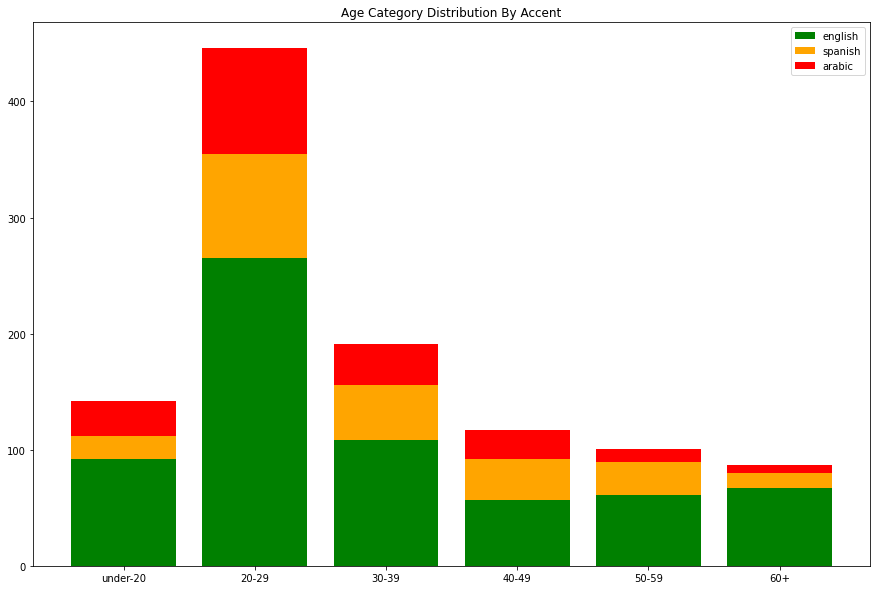

In [7]:
from helpers import *

speech_accent_age_distribution_by_accent(speech_accent_df)

If you breakdown the same barchart by accent, the above barchart indicates that most speakers are from english speaking countries.

### Audio Samples

Here, we would like a statistical summary of the duration of all samples from the Speech Accent Archive dataset. Some spectrograms in this section were plotted as well.

In [8]:
from helpers import *

mp3_filepaths = speech_accent_df['filename'].apply(
    lambda filename: './datasets/speech_accent_archive/clips/%s' % filename
)
durations = mp3_filepaths.apply(
    lambda mp3_filepath: audio_duration(mp3_filepath)
)
durations.describe()

count    1084.000000
mean       26.752451
std         8.388531
min        16.460544
25%        21.319796
50%        24.107358
75%        29.841950
max        91.325692
Name: filename, dtype: float64

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


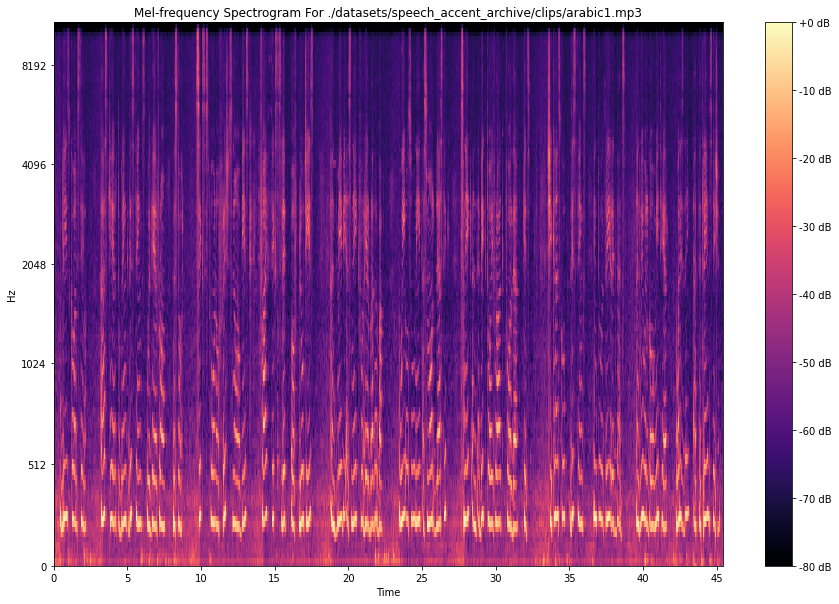

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


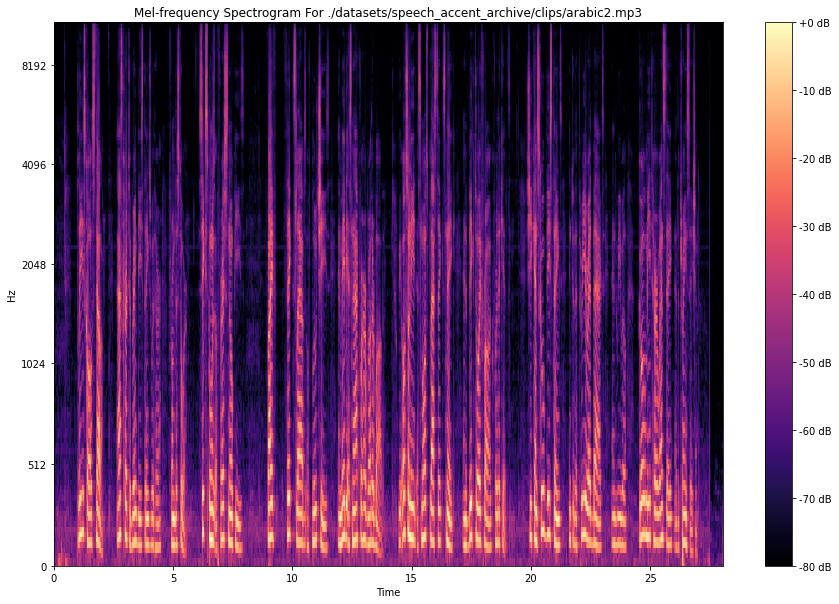

In [9]:
display_melspectrogram('./datasets/speech_accent_archive/clips/arabic1.mp3')
display_melspectrogram('./datasets/speech_accent_archive/clips/arabic2.mp3')

## Common Voice

### Metadata

In [10]:
import pandas as pd

common_voice_df = pd.read_csv("./datasets/common_voice/metadata.csv")
common_voice_df

,filename,up_votes,down_votes,locale,gender,accent,age
0,common_voice_en_33532190.mp3,2,0,en,male,NaN,twenties
1,common_voice_en_18295850.mp3,2,0,en,male,NaN,twenties
2,common_voice_en_32371106.mp3,2,0,en,male,NaN,sixties
3,common_voice_en_32642818.mp3,2,0,en,female,NaN,seventies
4,common_voice_en_22338655.mp3,3,1,en,female,Hong Kong English,twenties
...,...,...,...,...,...,...,...
1354416,common_voice_en_34925852.mp3,0,0,en,female,United States English,thirties
1354417,common_voice_en_34925854.mp3,0,0,en,female,United States English,thirties
1354418,common_voice_en_34925850.mp3,0,0,en,female,United States English,thirties
1354419,common_voice_en_34925856.mp3,0,0,en,female,United States English,thirties


There are a number of rows that have missing data. To solve this issue, all missing values will be replaced by a question mark ("?").

In [11]:
common_voice_df.fillna("?", inplace=True)
common_voice_df.to_csv("./datasets/common_voice/metadata(1).csv", index=False)
common_voice_df

,filename,up_votes,down_votes,locale,gender,accent,age
0,common_voice_en_33532190.mp3,2,0,en,male,?,twenties
1,common_voice_en_18295850.mp3,2,0,en,male,?,twenties
2,common_voice_en_32371106.mp3,2,0,en,male,?,sixties
3,common_voice_en_32642818.mp3,2,0,en,female,?,seventies
4,common_voice_en_22338655.mp3,3,1,en,female,Hong Kong English,twenties
...,...,...,...,...,...,...,...
1354416,common_voice_en_34925852.mp3,0,0,en,female,United States English,thirties
1354417,common_voice_en_34925854.mp3,0,0,en,female,United States English,thirties
1354418,common_voice_en_34925850.mp3,0,0,en,female,United States English,thirties
1354419,common_voice_en_34925856.mp3,0,0,en,female,United States English,thirties


All ages in the above dataframe are stored as categorical variables. Here are the possible categories:

In [12]:
common_voice_df.age.value_counts()

twenties     526643
thirties     282610
fourties     207138
teens        130609
fifties      101867
sixties       87648
seventies     15741
eighties       2018
nineties        147
Name: age, dtype: int64

To keep things consistent, let's modify the age column as before.

In [13]:
def get_age_category(age):
    if age == 'teens': return 'under-20'
    elif age == 'twenties': return '20-29'
    elif age == 'thirties': return '30-39'
    elif age == 'fourties': return '40-49'
    elif age == 'fifties': return '50-59'
    else: return '60+'

common_voice_df.age = common_voice_df.age.apply(lambda age: get_age_category(age))
common_voice_df.to_csv("./datasets/common_voice/metadata(1).csv", index=False)
common_voice_df

,filename,up_votes,down_votes,locale,gender,accent,age
0,common_voice_en_33532190.mp3,2,0,en,male,?,20-29
1,common_voice_en_18295850.mp3,2,0,en,male,?,20-29
2,common_voice_en_32371106.mp3,2,0,en,male,?,60+
3,common_voice_en_32642818.mp3,2,0,en,female,?,60+
4,common_voice_en_22338655.mp3,3,1,en,female,Hong Kong English,20-29
...,...,...,...,...,...,...,...
1354416,common_voice_en_34925852.mp3,0,0,en,female,United States English,30-39
1354417,common_voice_en_34925854.mp3,0,0,en,female,United States English,30-39
1354418,common_voice_en_34925850.mp3,0,0,en,female,United States English,30-39
1354419,common_voice_en_34925856.mp3,0,0,en,female,United States English,30-39


Now that we assigned ages into age categories, we will create a bar chart that describes the age catgeory distribution.

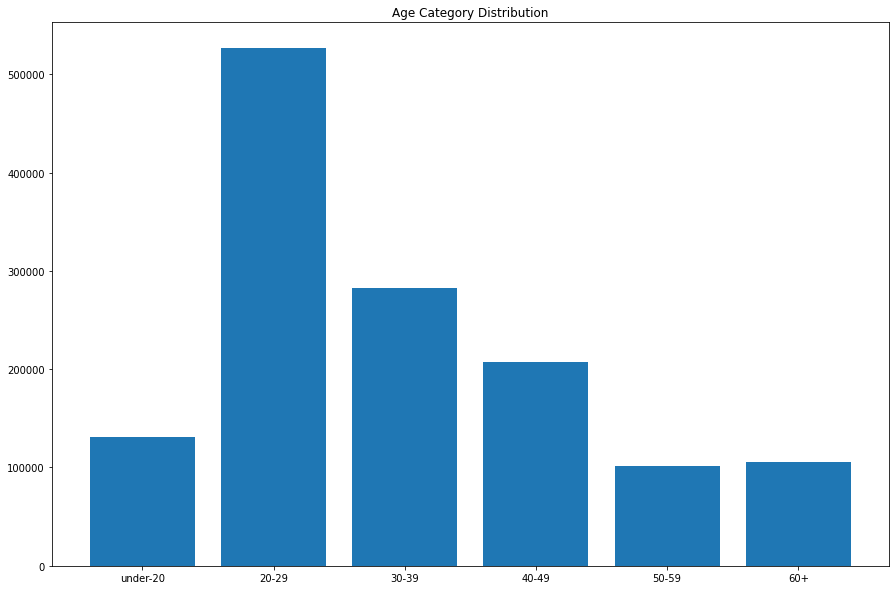

In [14]:
from helpers import *

age_distribution(common_voice_df)

The Age Category Distribution for the Common Voice Dataset is very similar to the Age Category Distribution for the Speech Accent Archive.

In [15]:
common_voice_df.gender.value_counts()

male      974534
female    331082
other      42803
?           6002
Name: gender, dtype: int64

Unexpectedly, there is a gender called "other" and this might refer to non-binary genders.

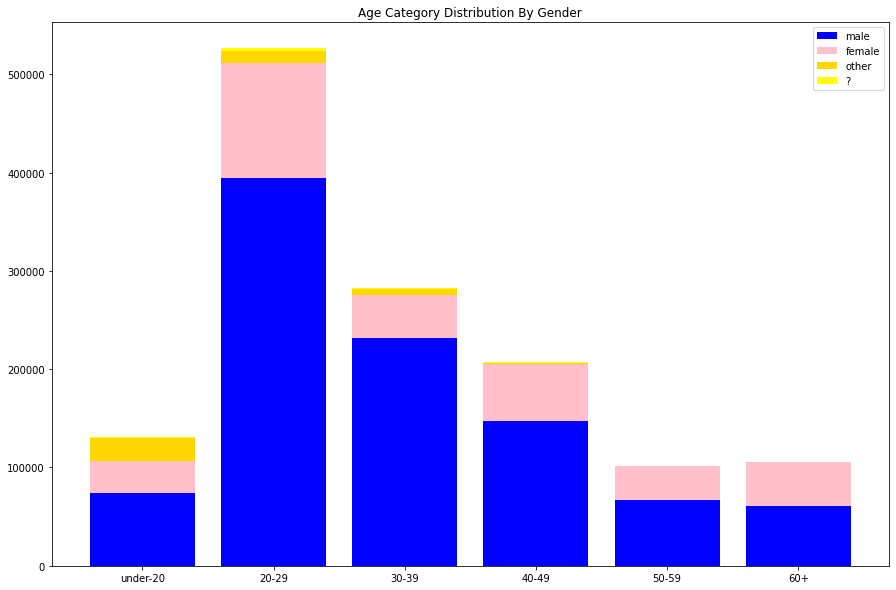

In [16]:
from helpers import *

common_voice_age_distribution_by_gender(common_voice_df)

Mos speakers in the Common Voice dataset are male.

In [17]:
common_voice_df.accent.value_counts()

United States English                                                                                          445017
?                                                                                                              323372
England English                                                                                                157379
India and South Asia (India, Pakistan, Sri Lanka)                                                              134431
Canadian English                                                                                                70776
                                                                                                                ...  
Swedish English                                                                                                     5
Scottish English,Edinburgh                                                                                          2
United States English,i have some pronunciation issues b

There are too many accents in this dataset, some of them are labelled as comments. Since accents should not contribute the age of a speaker, let's remove it.

In [18]:
common_voice_df.drop(columns=['accent'], inplace=True)
common_voice_df.to_csv("./datasets/common_voice/metadata(1).csv", index=False)
common_voice_df

,filename,up_votes,down_votes,locale,gender,age
0,common_voice_en_33532190.mp3,2,0,en,male,20-29
1,common_voice_en_18295850.mp3,2,0,en,male,20-29
2,common_voice_en_32371106.mp3,2,0,en,male,60+
3,common_voice_en_32642818.mp3,2,0,en,female,60+
4,common_voice_en_22338655.mp3,3,1,en,female,20-29
...,...,...,...,...,...,...
1354416,common_voice_en_34925852.mp3,0,0,en,female,30-39
1354417,common_voice_en_34925854.mp3,0,0,en,female,30-39
1354418,common_voice_en_34925850.mp3,0,0,en,female,30-39
1354419,common_voice_en_34925856.mp3,0,0,en,female,30-39


Now that we have a cleaned our metadata dataframe, we will need to split it into three parts:
 * **Training** - (80%)
 * **Validation** - (10%)
 * **Testing** - (10%)

In [19]:
from sklearn.model_selection import train_test_split

training_df, testing_df = train_test_split(
    common_voice_df, 
    test_size=0.10, 
    random_state=42, 
    shuffle=True
)
training_df, validation_df = train_test_split(
    training_df,
    test_size=0.125,
    random_state=42,
    shuffle=True
)
testing_df.to_csv("./datasets/common_voice/testing.csv", index=False)
training_df.to_csv("./datasets/common_voice/training.csv", index=False)
validation_df.to_csv("./datasets/common_voice/validation.csv", index=False)

### Audio Samples

Since we split our main dataset into three parts, we would like to know if their age category distrubtions are similar. Turns out to be true.

In [20]:
import pandas as pd
from helpers import *

training_df = pd.read_csv("./datasets/common_voice/training.csv")
validation_df = pd.read_csv("./datasets/common_voice/validation.csv")
testing_df = pd.read_csv("./datasets/common_voice/testing.csv")

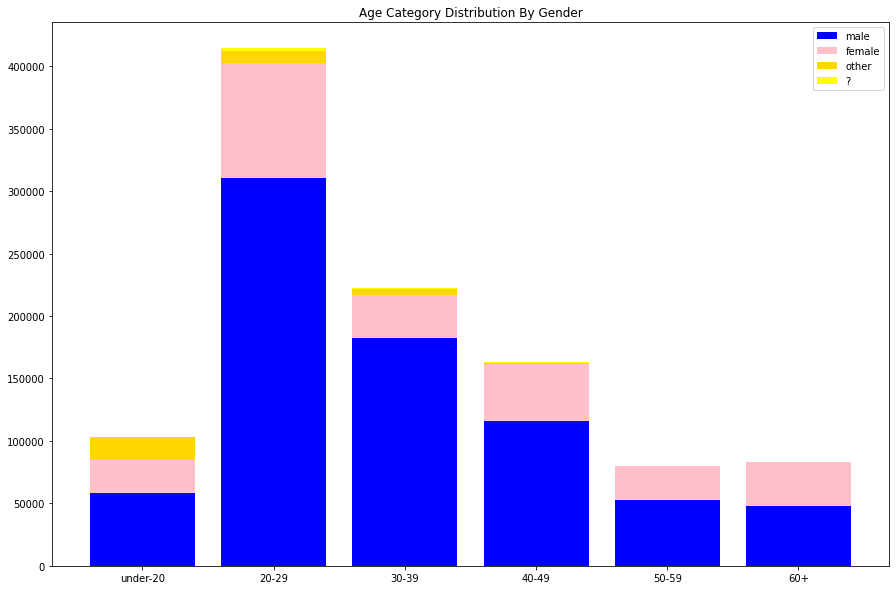

In [21]:
common_voice_age_distribution_by_gender(training_df)

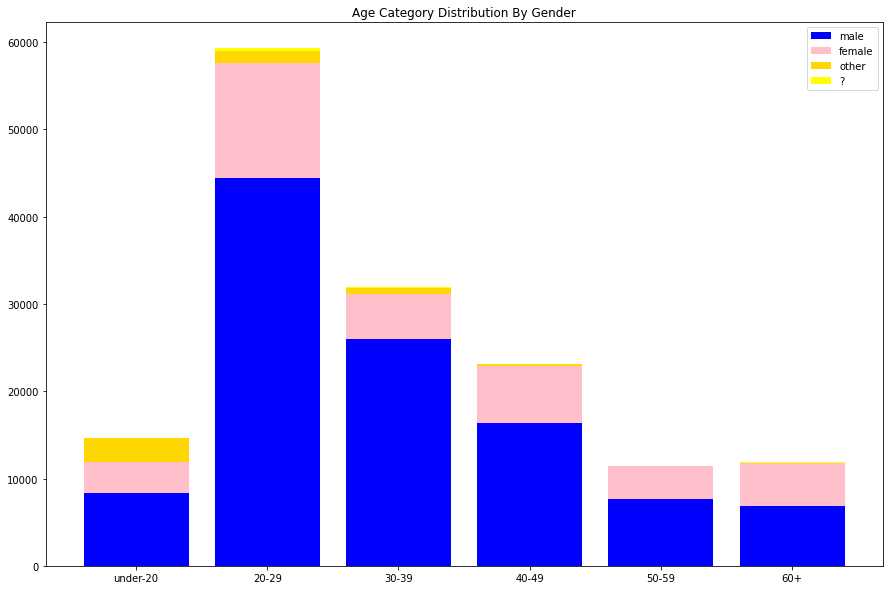

In [22]:
common_voice_age_distribution_by_gender(validation_df)

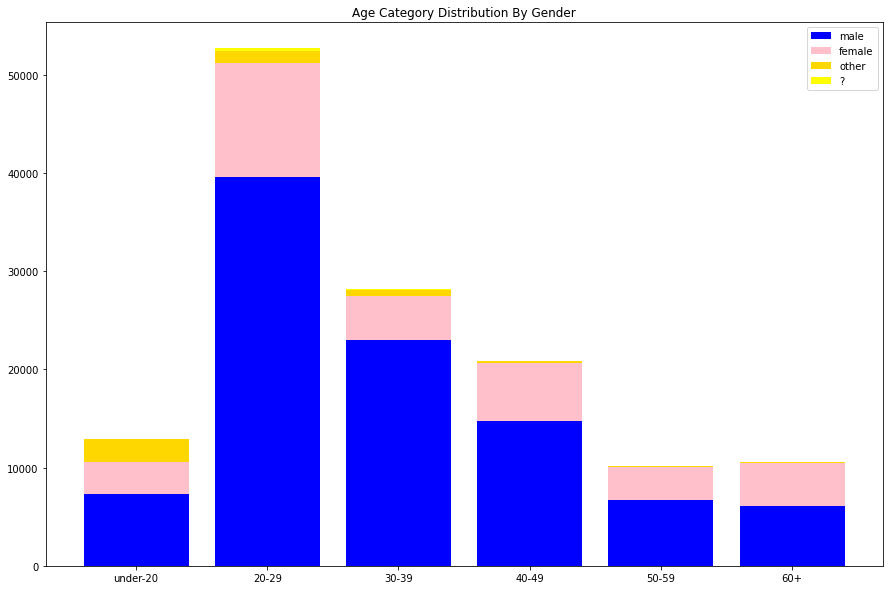

In [23]:
common_voice_age_distribution_by_gender(testing_df)

Here we would like to check the melspectrograms of each file that belongs to the training dataframe. Some melpsectragrams have regions where it is dark, i.e there is silence in the audio file.

In [24]:
import IPython

def preview_mp3(index):
    row = training_df.iloc[index]
    filename = row['filename']
    filepath = './datasets/common_voice/clips/%s' % filename
    
    up_votes, down_votes = row['up_votes'], row['down_votes']
    locale = row['locale']
    gender = row['gender']
    age = row['age']
    
    display_melspectrogram(filepath)
    
    print("Filepath: ", filepath)
    print("Up Votes: ", up_votes) 
    print("Down Votes: ", down_votes)
    print("Gender: ", gender)
    print("Age: ", age)

#### Melspectrograms

##### under-20

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


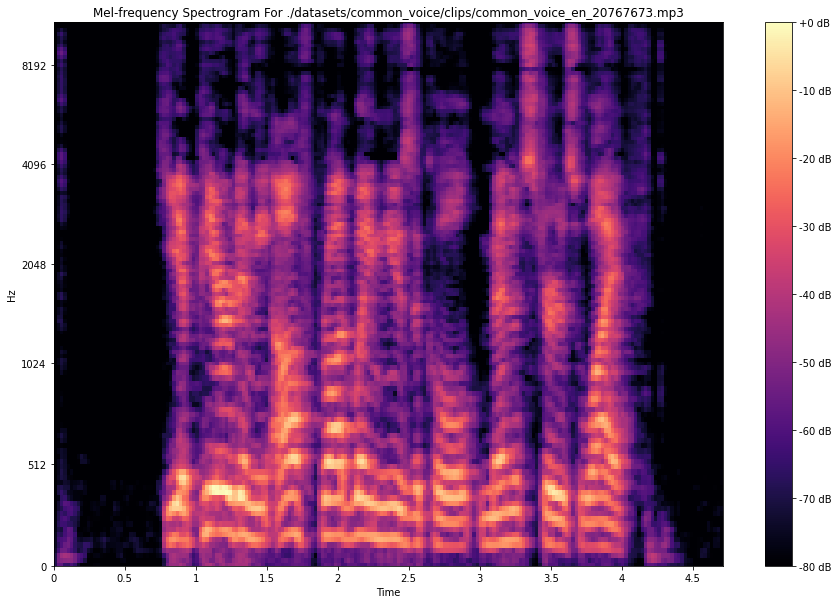

Filepath:  ./datasets/common_voice/clips/common_voice_en_20767673.mp3
Up Votes:  2
Down Votes:  0
Gender:  male
Age:  20-29


In [25]:
preview_mp3(8)

In [26]:
IPython.display.Audio('./datasets/common_voice/clips/common_voice_en_26022530.mp3')

##### 20-29

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


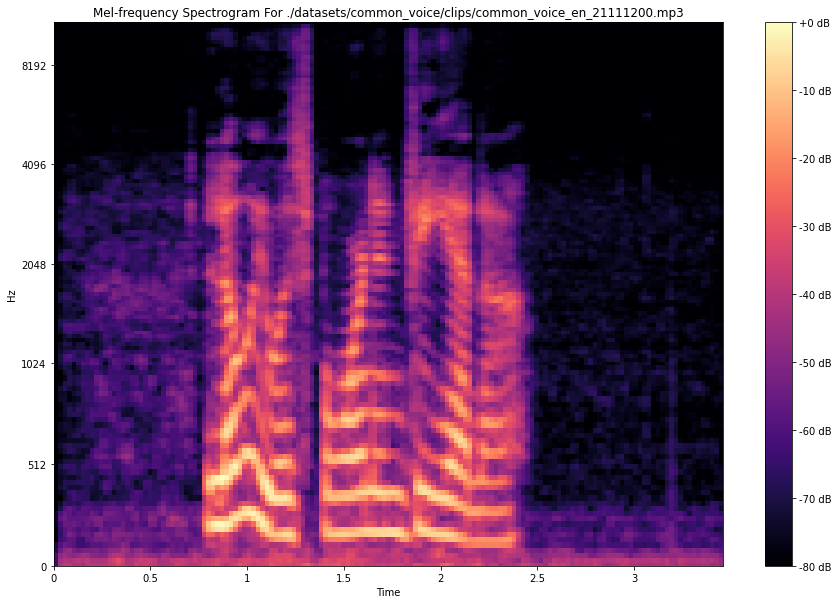

Filepath:  ./datasets/common_voice/clips/common_voice_en_21111200.mp3
Up Votes:  2
Down Votes:  0
Gender:  female
Age:  50-59


In [27]:
preview_mp3(9)

In [28]:
IPython.display.Audio('./datasets/common_voice/clips/common_voice_en_22333021.mp3')

##### 30-39

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


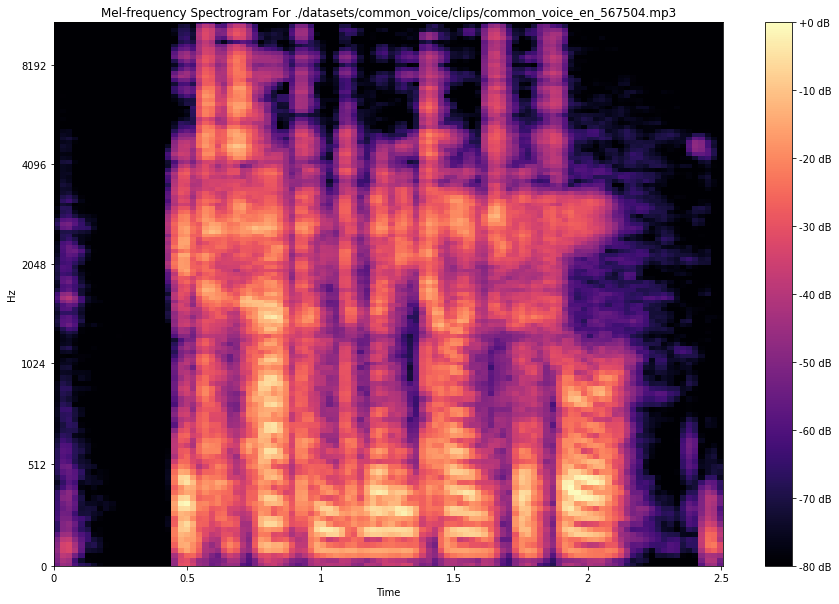

Filepath:  ./datasets/common_voice/clips/common_voice_en_567504.mp3
Up Votes:  2
Down Votes:  0
Gender:  male
Age:  20-29


In [29]:
preview_mp3(0)

In [30]:
IPython.display.Audio('./datasets/common_voice/clips/common_voice_en_19757314.mp3')

#### 40-49

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


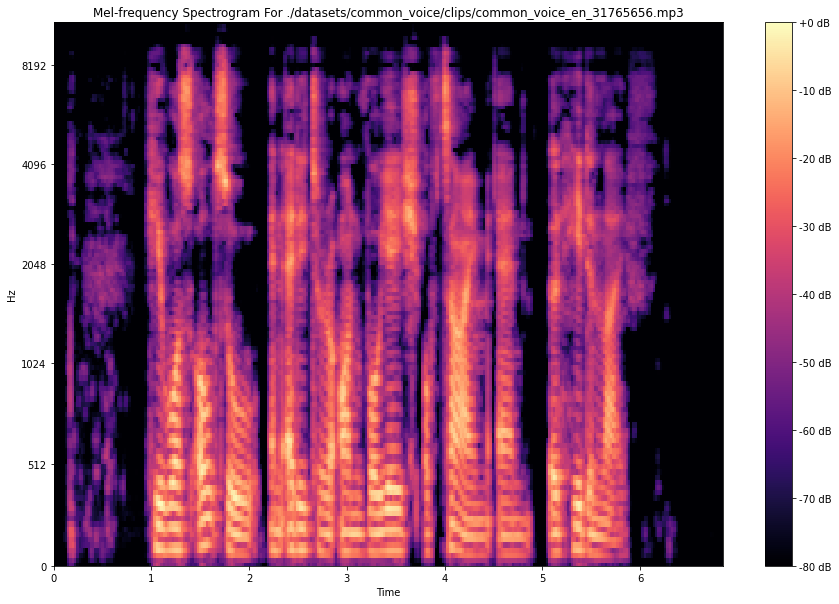

Filepath:  ./datasets/common_voice/clips/common_voice_en_31765656.mp3
Up Votes:  1
Down Votes:  0
Gender:  male
Age:  20-29


In [31]:
preview_mp3(5)

In [32]:
IPython.display.Audio('./datasets/common_voice/clips/common_voice_en_23951358.mp3')

#### 50-59

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


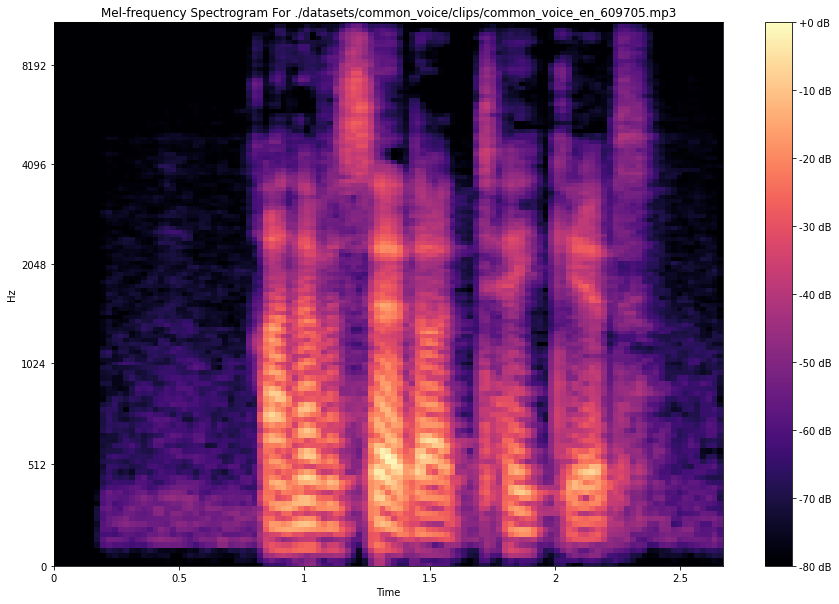

Filepath:  ./datasets/common_voice/clips/common_voice_en_609705.mp3
Up Votes:  3
Down Votes:  0
Gender:  male
Age:  40-49


In [33]:
preview_mp3(4)

In [34]:
IPython.display.Audio('./datasets/common_voice/clips/common_voice_en_547214.mp3')

#### 60+

/home/xnell90/anaconda3/envs/tf2-gpu/lib/python3.9/site-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


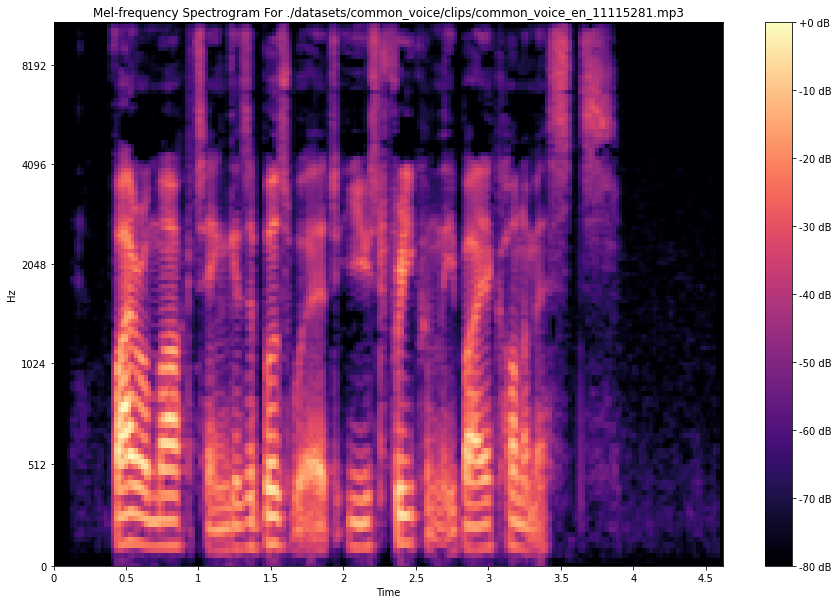

Filepath:  ./datasets/common_voice/clips/common_voice_en_11115281.mp3
Up Votes:  2
Down Votes:  0
Gender:  male
Age:  30-39


In [35]:
preview_mp3(13)

In [36]:
IPython.display.Audio('./datasets/common_voice/clips/common_voice_en_21806781.mp3')

#### Other Features

There are other features that we would like to extract from an audio file. Examples include:
 * MFCCs
 * Spectral Bandwidth
 * Spectral Centroid
 * Spectral Rolloff
 
However for now, we would like to check if we can only use melspectrograms to estimate the speaker's age.